<a href="https://colab.research.google.com/github/krawiecdrew-boop/MeanandMomentumBacktester/blob/main/Machine_Learning_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#THE REPORT IS NOT INCLUDED IN MY SUBMISSION, THIS IS BECAUSE my code either prints, plots,
# or has comments disscusing each of the required points in the report.
#PART A
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from google.colab import drive # Access 1979 file from drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import xarray as xr #Opens file and verfiies dimensions, shape, and pressure levels

ds = xr.open_dataset('/content/drive/MyDrive/Colab Notebooks/z1979.nc')
z = ds["z"]

print("FULL DATASET INFO:")
print(ds)
print("\nShape of z:", z.shape) # This prints/confirms our dataset shape
print("\nPressure levels:", ds["level"].values)


FULL DATASET INFO:
<xarray.Dataset> Size: 383MB
Dimensions:    (time: 1460, level: 2, latitude: 91, longitude: 180)
Coordinates:
  * time       (time) datetime64[ns] 12kB 1979-01-01 ... 1979-12-31T18:00:00
  * level      (level) int32 8B 50 500
  * latitude   (latitude) float32 364B 90.0 88.0 86.0 84.0 ... -86.0 -88.0 -90.0
  * longitude  (longitude) float32 720B -180.0 -178.0 -176.0 ... 176.0 178.0
Data variables:
    z          (time, level, latitude, longitude) float64 383MB ...
Attributes:
    Conventions:  CF-1.6
    history:      2022-03-22 00:50:56 GMT by grib_to_netcdf-2.24.2: /opt/ecmw...

Shape of z: (1460, 2, 91, 180)

Pressure levels: [ 50 500]


In [ ]:
time_diff = ds["time"][1] - ds["time"][0]
print("\nTime step between samples:", time_diff)

# 3. Print latitude and longitude arrays
print("\nLatitude array shape:", ds["latitude"].shape)
print("Longitude array shape:", ds["longitude"].shape)

print("\nFirst 5 latitudes:", ds["latitude"].values[:5])
print("First 5 longitudes:", ds["longitude"].values[:5])


Time step between samples: <xarray.DataArray 'time' ()> Size: 8B
array(21600000000000, dtype='timedelta64[ns]')
Attributes:
    long_name:  time

Latitude array shape: (91,)
Longitude array shape: (180,)

First 5 latitudes: [90. 88. 86. 84. 82.]
First 5 longitudes: [-180. -178. -176. -174. -172.]


In [ ]:
T = z.shape[0]
time_indices = [0, T//3, 2*T//3, T-1] #Creates our 4 time snapshots for the year 1979

lat = ds["latitude"].values
lon = ds["longitude"].values


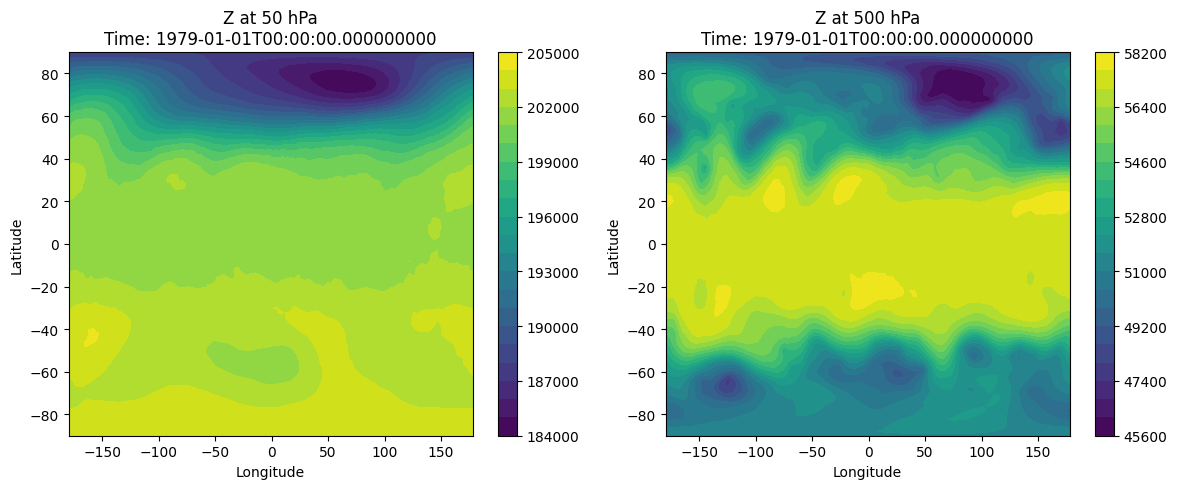

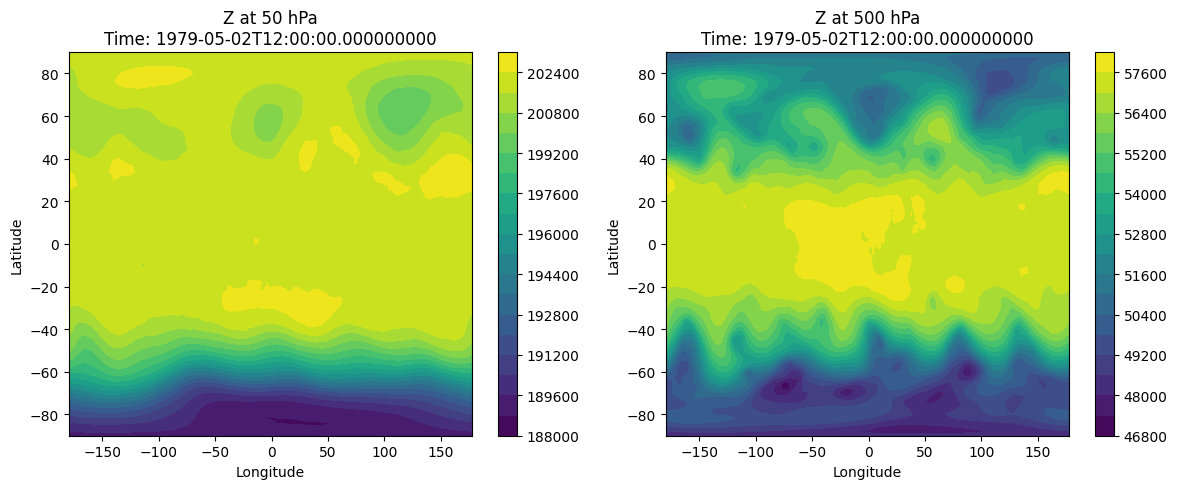

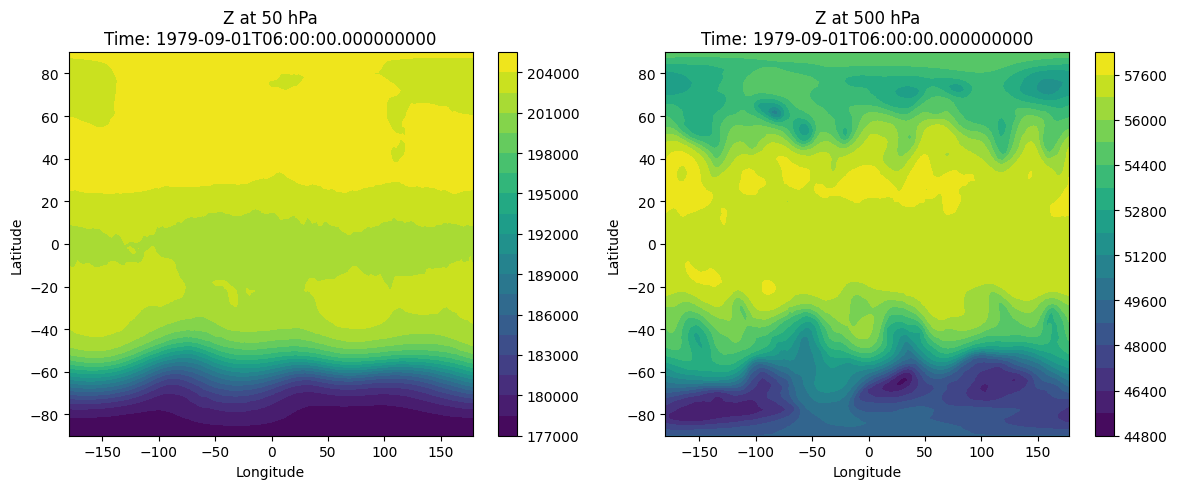

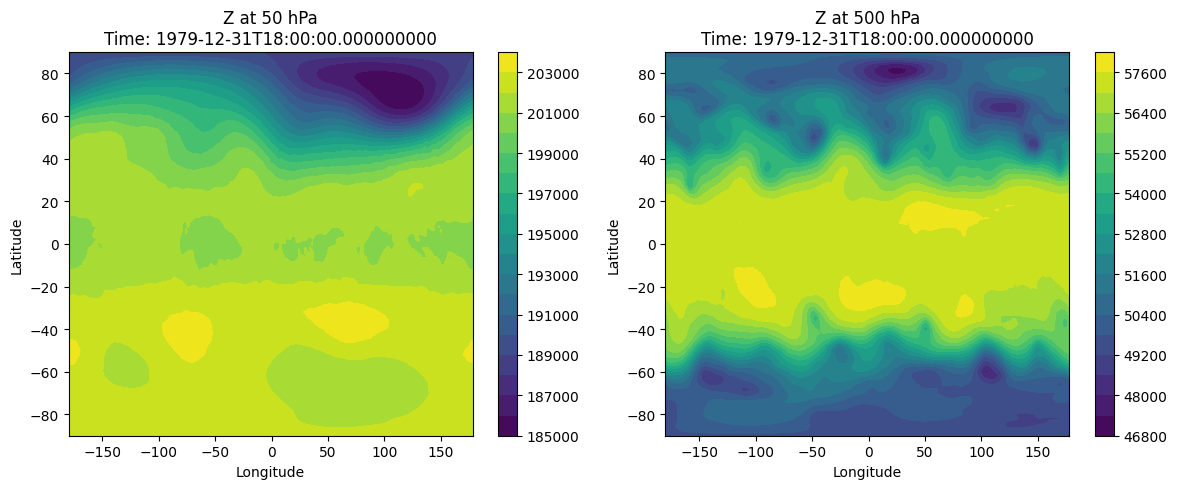

In [ ]:
#Plots of contour maps
for t in time_indices:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # 50 hPa
    cs1 = axes[0].contourf(lon, lat, z[t, 0, :, :], levels=20)
    axes[0].set_title(f"Z at 50 hPa\nTime: {str(ds['time'].values[t])}")
    axes[0].set_xlabel("Longitude")
    axes[0].set_ylabel("Latitude")
    plt.colorbar(cs1, ax=axes[0])

    # 500 hPa
    cs2 = axes[1].contourf(lon, lat, z[t, 1, :, :], levels=20)
    axes[1].set_title(f"Z at 500 hPa\nTime: {str(ds['time'].values[t])}")
    axes[1].set_xlabel("Longitude")
    axes[1].set_ylabel("Latitude")
    plt.colorbar(cs2, ax=axes[1])

    plt.tight_layout()
    plt.show()

In [ ]:
#PART B
#Training, validation, and test data
import torch
from torch.utils.data import Dataset, DataLoader

# Convert to numpy (T, C, H, W)
data = z.values

T = data.shape[0]

# Split indices by time
train_end = int(0.7 * T)
val_end = int(0.85 * T)

train_data = data[:train_end]
val_data   = data[train_end:val_end]
test_data  = data[val_end:]

print("Train shape:", train_data.shape)
print("Val shape:", val_data.shape)
print("Test shape:", test_data.shape)

Train shape: (1021, 2, 91, 180)
Val shape: (220, 2, 91, 180)
Test shape: (219, 2, 91, 180)


In [ ]:
#Normalization Process
# Compute per-channel mean/std over train set
mean = train_data.mean(axis=(0, 2, 3), keepdims=True)
std  = train_data.std(axis=(0, 2, 3), keepdims=True)

print("Channel means:", mean.flatten())
print("Channel stds:", std.flatten())



Channel means: [199665.2325009   54061.69986323]
Channel stds: [6257.54616067 3416.32905995]


In [ ]:
#Z score normalization
train_data = (train_data - mean) / std
val_data   = (val_data   - mean) / std
test_data  = (test_data  - mean) / std

In [ ]:
#Dataset for 1 step training, building ground truth target pairs of (xt, xt+1)
class OneStepDataset(Dataset):
    def __init__(self, data):
        self.data = torch.tensor(data, dtype=torch.float32)

    def __len__(self):
        return self.data.shape[0] - 1

    def __getitem__(self, idx):
        x_t = self.data[idx]
        x_tp1 = self.data[idx + 1]
        return x_t, x_tp1
#Data loaders
batch_size = 8

train_dataset = OneStepDataset(train_data)
val_dataset   = OneStepDataset(val_data)
test_dataset  = OneStepDataset(test_data)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size)
test_loader  = DataLoader(test_dataset, batch_size=batch_size)

print("Train batches:", len(train_loader))

Train batches: 128


In [ ]:
#Data for multistep training, ground truth pairs but pairs are k data points
class MultiStepDataset(Dataset):
    def __init__(self, data, K):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.K = K

    def __len__(self):
        return self.data.shape[0] - self.K

    def __getitem__(self, idx):
        x_seq = self.data[idx : idx + self.K + 1]
        x_t = x_seq[0]
        future = x_seq[1:]
        return x_t, future

In [ ]:
#PART C
#baseline cnn model
import torch.nn as nn


# BaselineCNN:
# 4 convolutional layers
# 3 ReLU activations
# 3x3 kernels for all layers
# 2 input channels
# 32 hidden channels in middle layers
# 2 output channels

class BaselineCNN(nn.Module):
    def __init__(self, hidden_channels=32):
        super().__init__()

        #Start with 2 feature maps [50,500], we have 32 different
        #filters/kernels that slide over the 2 and outputs 32 sets of feature
        #maps, we then repeat this process over the now 32 feature maps and
        #then in the last layer squeeze it back to 2.

        self.net = nn.Sequential(
            nn.Conv2d(2, hidden_channels, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(hidden_channels, hidden_channels, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(hidden_channels, hidden_channels, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(hidden_channels, 2, kernel_size=3, padding=1)
        )

    def forward(self, x):
        return self.net(x)

class TendencyCNN(nn.Module):
    def __init__(self, hidden_channels=32):
        super().__init__()

        # SAME architecture as BaselineCNN
        self.net = nn.Sequential(
            nn.Conv2d(2, hidden_channels, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(hidden_channels, hidden_channels, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(hidden_channels, hidden_channels, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(hidden_channels, 2, kernel_size=3, padding=1)
        )

    def forward(self, x):
        return self.net(x)   # predicts f_theta(x)



#Resnet CNN, same concept just using resnet now
# 8 convolutional layers total (1 input, 3 blocks × 2 convs, 1 output)
# ReLU after input conv and within each ResBlock
# 3x3 kernels for all layers
# 2 input channels
# 32 hidden channels in residual blocks
# 2 output channels
class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)

    def forward(self, x):
        return x + self.conv2(self.relu(self.conv1(x)))  # residual connection

class ResNetCNN(nn.Module):
    def __init__(self, hidden_channels=32, num_blocks=3):
        super().__init__()
        self.input_conv = nn.Conv2d(2, hidden_channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.res_blocks = nn.Sequential(
            *[ResBlock(hidden_channels) for _ in range(num_blocks)]
        )
        self.output_conv = nn.Conv2d(hidden_channels, 2, kernel_size=3, padding=1)

    def forward(self, x):
        x = self.relu(self.input_conv(x))
        x = self.res_blocks(x)
        x = self.output_conv(x)
        return x

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Parameters

device = "cuda" if torch.cuda.is_available() else "cpu"
num_epochs = 10 #how many times we loop over entire data set
batch_size = 16
learning_rate = 1e-3


train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


# Instantiate model, loss, optimizer
model = BaselineCNN(hidden_channels=32).to(device) #Can change to resnet as well
#to see paramter count and differnet loss values.
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
#Using adam optimizer


# Training loop (one-step MSE)
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        y_pred = model(x_batch) #data fed into our CNN
        loss = criterion(y_pred, y_batch) #prediction at future time step
        # - value at true future time step
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * x_batch.size(0)

    train_loss /= len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            y_pred = model(x_batch)
            loss = criterion(y_pred, y_batch)
            val_loss += loss.item() * x_batch.size(0)
    val_loss /= len(val_loader.dataset)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")


# Report model details
from torchsummary import summary

H = train_data.shape[2]
W = train_data.shape[3]

summary(model, input_size=(2, H, W))

print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")

Epoch 1/10 | Train Loss: 72.324319 | Val Loss: 4.033769
Epoch 2/10 | Train Loss: 2.412164 | Val Loss: 1.344875
Epoch 3/10 | Train Loss: 0.841967 | Val Loss: 0.407340
Epoch 4/10 | Train Loss: 0.176778 | Val Loss: 0.040900
Epoch 5/10 | Train Loss: 0.021841 | Val Loss: 0.016086
Epoch 6/10 | Train Loss: 0.014007 | Val Loss: 0.012142
Epoch 7/10 | Train Loss: 0.010500 | Val Loss: 0.008869
Epoch 8/10 | Train Loss: 0.007610 | Val Loss: 0.006391
Epoch 9/10 | Train Loss: 0.005471 | Val Loss: 0.004641
Epoch 10/10 | Train Loss: 0.004012 | Val Loss: 0.003439
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 32, 91, 180]             608
              ReLU-2          [-1, 32, 91, 180]               0
            Conv2d-3          [-1, 32, 91, 180]           9,248
              ReLU-4          [-1, 32, 91, 180]               0
            Conv2d-5          [-1, 32, 91, 180]           9,248

In [ ]:
# PART D Multi-step autoregressive training

K = 8  # rollout horizon (8 steps = 2 days), 2 day predcition is reasonable and important
gamma = 0.9  # decay factor for multi-step loss, (exponentially decaying importance for further steps)
# This emphasizes short-term predictions more than distant future,
# reflecting that nearby time steps are strongly correlated and easier to predict,
# while longer horizons are more uncertain and errors compound.

batch_size = 8  # smaller because multi-step uses more memory
num_epochs = 10


# Create MultiStep Datasets
train_multi_dataset = MultiStepDataset(train_data, K)
val_multi_dataset   = MultiStepDataset(val_data, K)

train_loader = DataLoader(train_multi_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_multi_dataset, batch_size=batch_size, shuffle=False)

# Instantiate model, loss, optimizer
model = BaselineCNN(hidden_channels=32).to(device)
# can switch to resnet as well

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Precompute weights for K-step loss
weights = torch.tensor([gamma**k for k in range(K)], device=device)


# Training loop (multi-step loss)

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for x_batch, y_batch_seq in train_loader:
        x_batch = x_batch.to(device)
        y_batch_seq = y_batch_seq.to(device)  # shape [B, K, 2, H, W]

        optimizer.zero_grad()
        x_in = x_batch
        loss = 0.0

        # Autoregressive rollout
        for k in range(K):
            x_out = model(x_in)
            loss += weights[k] * criterion(x_out, y_batch_seq[:, k, :, :, :])
            x_in = x_out.detach()  # detach to prevent backprop through all steps

        loss.backward()
        optimizer.step()
        train_loss += loss.item() * x_batch.size(0)

    train_loss /= len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch_seq in val_loader:
            x_batch = x_batch.to(device)
            y_batch_seq = y_batch_seq.to(device)
            x_in = x_batch
            loss = 0.0
            for k in range(K):
                x_out = model(x_in)
                loss += weights[k] * criterion(x_out, y_batch_seq[:, k, :, :, :])
                x_in = x_out.detach()
            val_loss += loss.item() * x_batch.size(0)

    val_loss /= len(val_loader.dataset)
    print(f"Epoch {epoch+1}/{num_epochs} | Train Multi-step Loss: {train_loss:.6f} | Val Multi-step Loss: {val_loss:.6f}")

Epoch 1/10 | Train Multi-step Loss: 631.690608 | Val Multi-step Loss: 3.325481
Epoch 2/10 | Train Multi-step Loss: 0.787993 | Val Multi-step Loss: 0.239304
Epoch 3/10 | Train Multi-step Loss: 0.202322 | Val Multi-step Loss: 0.172085
Epoch 4/10 | Train Multi-step Loss: 0.150824 | Val Multi-step Loss: 0.133472
Epoch 5/10 | Train Multi-step Loss: 0.120230 | Val Multi-step Loss: 0.108281
Epoch 6/10 | Train Multi-step Loss: 0.181694 | Val Multi-step Loss: 0.090297
Epoch 7/10 | Train Multi-step Loss: 0.203016 | Val Multi-step Loss: 0.077112
Epoch 8/10 | Train Multi-step Loss: 0.290700 | Val Multi-step Loss: 0.077492
Epoch 9/10 | Train Multi-step Loss: 0.062919 | Val Multi-step Loss: 0.057798
Epoch 10/10 | Train Multi-step Loss: 0.422546 | Val Multi-step Loss: 0.051319


BaselineCNN Epoch 1 | Train Loss: 74.4551
BaselineCNN Epoch 2 | Train Loss: 0.5290
BaselineCNN Epoch 3 | Train Loss: 0.0192
BaselineCNN Epoch 4 | Train Loss: 0.0099
BaselineCNN Epoch 5 | Train Loss: 0.0060
ResNetCNN Epoch 1 | Train Loss: 46.2579
ResNetCNN Epoch 2 | Train Loss: 0.0986
ResNetCNN Epoch 3 | Train Loss: 0.0240
ResNetCNN Epoch 4 | Train Loss: 0.0167
ResNetCNN Epoch 5 | Train Loss: 0.0165
Euler Epoch 1 | Train Loss: 3.6726
Euler Epoch 2 | Train Loss: 0.0004
Euler Epoch 3 | Train Loss: 0.0002
Euler Epoch 4 | Train Loss: 0.0001
Euler Epoch 5 | Train Loss: 0.0001
RK4 Epoch 1 | Train Loss: 0.4230
RK4 Epoch 2 | Train Loss: 0.0020
RK4 Epoch 3 | Train Loss: 0.0011
RK4 Epoch 4 | Train Loss: 0.0006
RK4 Epoch 5 | Train Loss: 0.0001


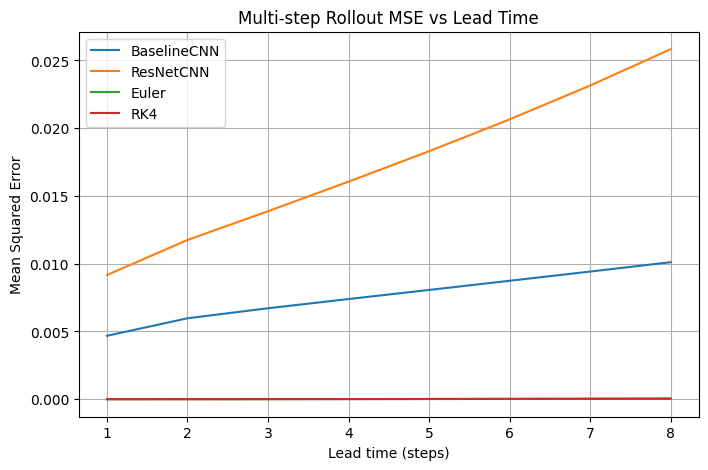

In [ ]:
# PART E Integration-Constrained Models (Euler & RK4)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

# Parameters

dt = 1.0
K = 8
gamma = 0.9
batch_size = 8
num_epochs_onestep = 5
num_epochs_multistep = 5

criterion = nn.MSELoss()
weights = torch.tensor([gamma**k for k in range(K)], device=device)


# Datasets & loaders

train_loader_onestep = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader_onestep   = DataLoader(val_dataset, batch_size=16)

train_multi_dataset = MultiStepDataset(train_data, K)
val_multi_dataset   = MultiStepDataset(val_data, K)
test_multi_dataset  = MultiStepDataset(test_data, K)

train_loader_multi = DataLoader(train_multi_dataset, batch_size=batch_size, shuffle=True)
val_loader_multi   = DataLoader(val_multi_dataset, batch_size=batch_size)
test_loader_multi  = DataLoader(test_multi_dataset, batch_size=4)


# Models

model_baseline = BaselineCNN(32).to(device)
model_resnet   = ResNetCNN(32, num_blocks=3).to(device)
f_theta_euler  = TendencyCNN(32).to(device)
f_theta_rk4    = TendencyCNN(32).to(device)


# Helper: One-step training

def train_one_step(model):
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(num_epochs_onestep):
        model.train()
        train_loss = 0.0

        for x, y in train_loader_onestep:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * x.size(0)

        train_loss /= len(train_loader_onestep.dataset)
        print(f"{model.__class__.__name__} Epoch {epoch+1} | Train Loss: {train_loss:.4f}")


# Train Baseline & ResNet

train_one_step(model_baseline)
train_one_step(model_resnet)


# Integration steps

def euler_step(x, f, dt):
    return x + dt * f(x)

def rk4_step(x, f, dt):
    k1 = f(x)
    k2 = f(x + 0.5 * dt * k1)
    k3 = f(x + 0.5 * dt * k2)
    k4 = f(x + dt * k3)
    return x + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)


# Multi-step training (Euler & RK4)

def train_integrator(f_theta, step_fn, name):
    optimizer = optim.Adam(f_theta.parameters(), lr=1e-3)

    for epoch in range(num_epochs_multistep):
        f_theta.train()
        total_loss = 0.0

        for x0, y_seq in train_loader_multi:
            x0, y_seq = x0.to(device), y_seq.to(device)

            optimizer.zero_grad()
            x = x0
            loss = 0.0

            for k in range(K):
                x = step_fn(x, f_theta, dt)
                loss += weights[k] * criterion(x, y_seq[:, k])

                x = x.detach()

            loss.backward()
            optimizer.step()
            total_loss += loss.item() * x0.size(0)

        total_loss /= len(train_loader_multi.dataset)
        print(f"{name} Epoch {epoch+1} | Train Loss: {total_loss:.4f}")

# Train Euler & RK4
train_integrator(f_theta_euler, euler_step, "Euler")
train_integrator(f_theta_rk4,   rk4_step,   "RK4")



# Unified multi-step evaluation

models = {
    "BaselineCNN": lambda x: model_baseline(x),
    "ResNetCNN":   lambda x: model_resnet(x),
    "Euler":       lambda x: euler_step(x, f_theta_euler, dt),
    "RK4":         lambda x: rk4_step(x, f_theta_rk4, dt)
}

mse = {name: np.zeros(K) for name in models}

with torch.no_grad():
    for x0, y_seq in test_loader_multi:
        x0, y_seq = x0.to(device), y_seq.to(device)

        for name, step in models.items():
            x = x0
            for k in range(K):
                x = step(x)
                mse[name][k] += ((x - y_seq[:, k])**2).mean().item()

# normalize
for name in mse:
    mse[name] /= len(test_loader_multi)


# Plot: Multi-step rollout error

plt.figure(figsize=(8,5))
for name, values in mse.items():
    plt.plot(range(1, K+1), values, label=name)

plt.xlabel("Lead time (steps)")
plt.ylabel("Mean Squared Error")
plt.title("Multi-step Rollout MSE vs Lead Time")
plt.legend()
plt.grid(True)
plt.show()

#Euler vs RK4 Constraints

#Euler
#With small normalized time steps (Δt = 1, corresponding to 6 hours),
#the single-step slope approximation is sufficient, and fewer intermediate
#computations reduce accumulated error from the learned Mθ’s noise.

#RK4
#RK4 relies on multiple evaluations of Mθ per step.
#While theoretically more accurate for smooth ODEs,
#here Mθ is a data-driven approximation with inherent approximation error.
#The additional intermediate slopes can amplify these errors,
#causing slightly higher multi-step forecast error.

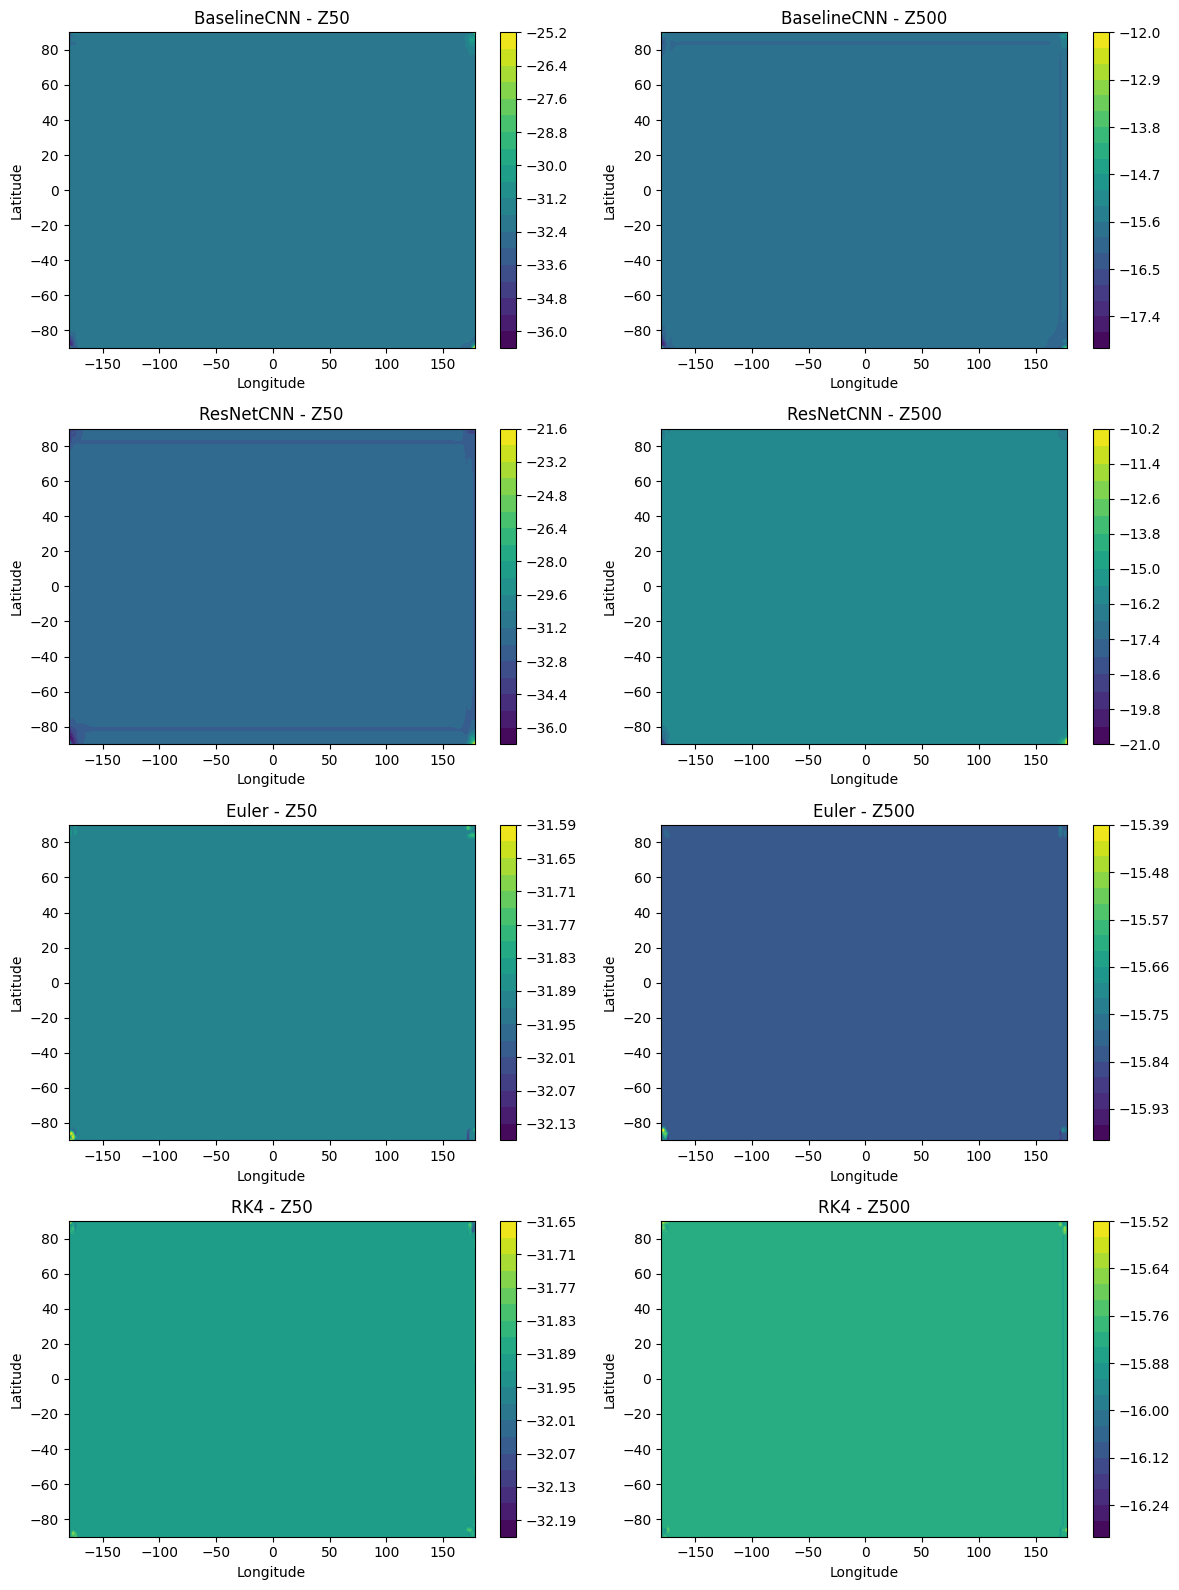

In [ ]:
# Evaluation / Comparison

# Plot example Z50 / Z500 contours at final step
x0, y_seq = test_dataset[0]
x0 = x0.unsqueeze(0).to(device)
lat = ds["latitude"].values
lon = ds["longitude"].values

fig, axes = plt.subplots(4, 2, figsize=(12,16))
for i, (name, model_step) in enumerate(models.items()):
    x_in = x0
    for k in range(K):
        x_out = model_step(x_in)
        x_in = x_out
    final_pred = x_out.detach().cpu().numpy()[0]

    axes[i, 0].contourf(lon, lat, final_pred[0], levels=20)
    axes[i, 0].set_title(f"{name} - Z50")
    axes[i, 0].set_xlabel("Longitude"); axes[i, 0].set_ylabel("Latitude")
    plt.colorbar(axes[i, 0].collections[0], ax=axes[i, 0])

    axes[i, 1].contourf(lon, lat, final_pred[1], levels=20)
    axes[i, 1].set_title(f"{name} - Z500")
    axes[i, 1].set_xlabel("Longitude"); axes[i, 1].set_ylabel("Latitude")
    plt.colorbar(axes[i, 1].collections[0], ax=axes[i, 1])

plt.tight_layout()
plt.show()

BaselineCNN one-step test MSE: 0.004681
ResNetCNN one-step test MSE: 0.009166
Euler one-step test MSE: 0.000001
RK4 one-step test MSE: 0.000001


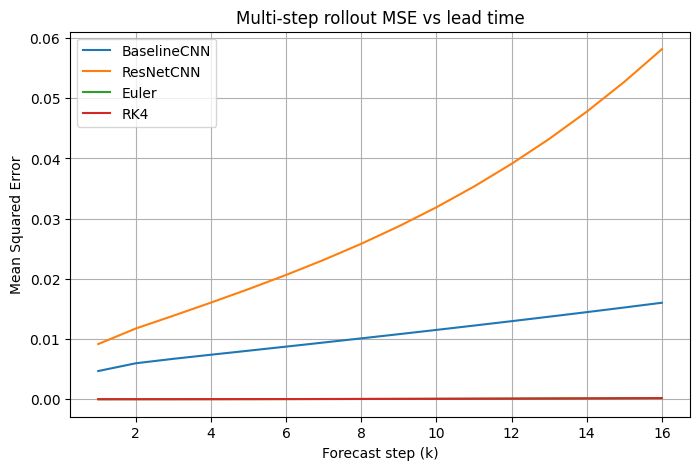

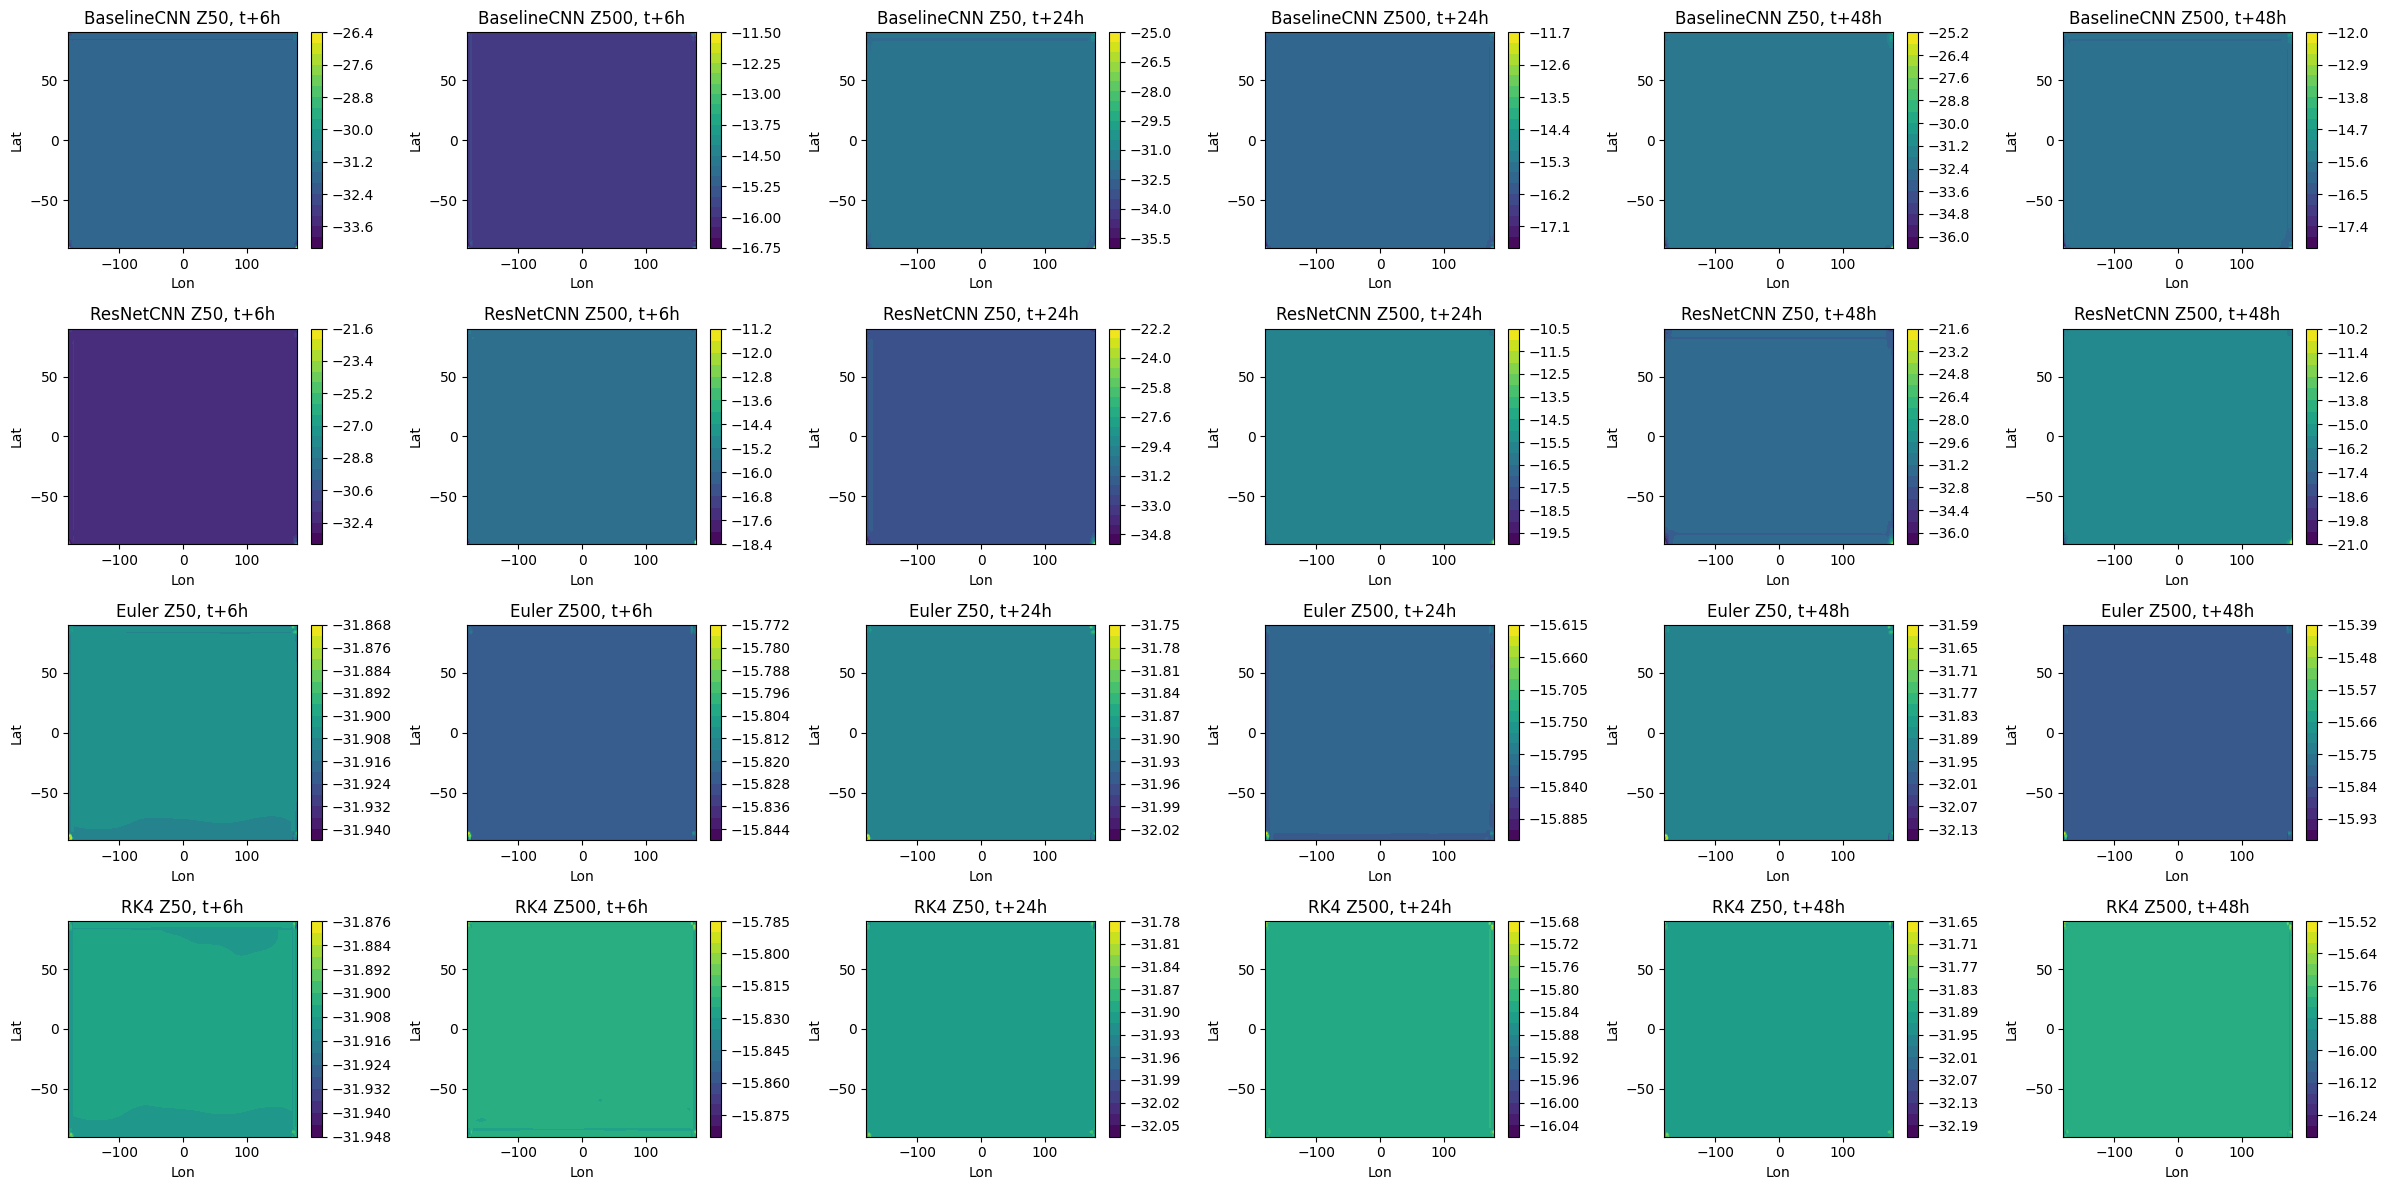

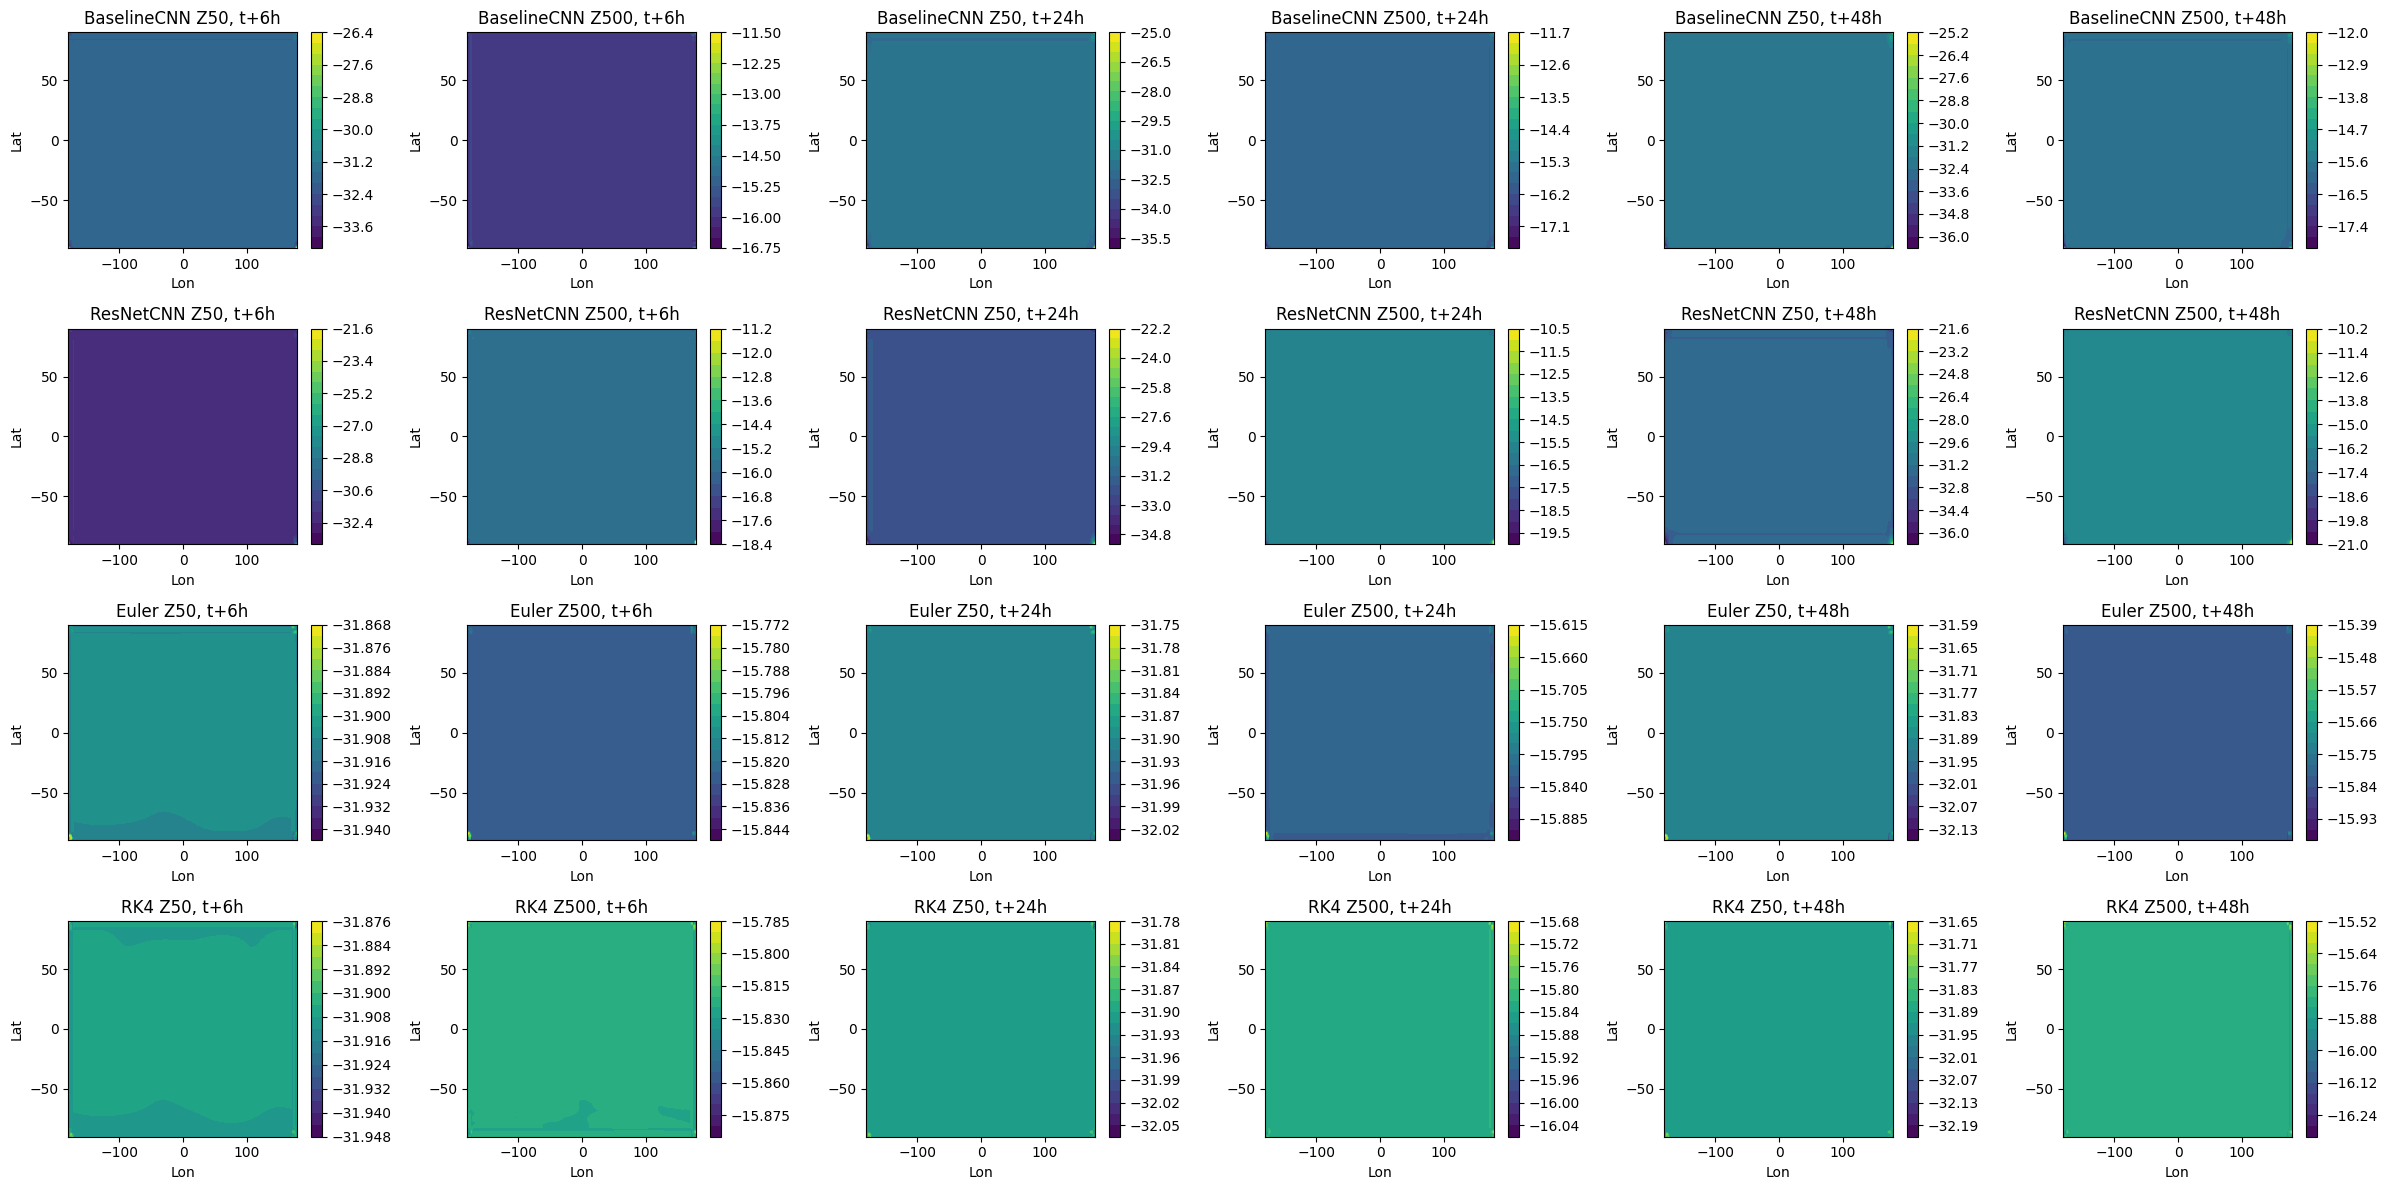

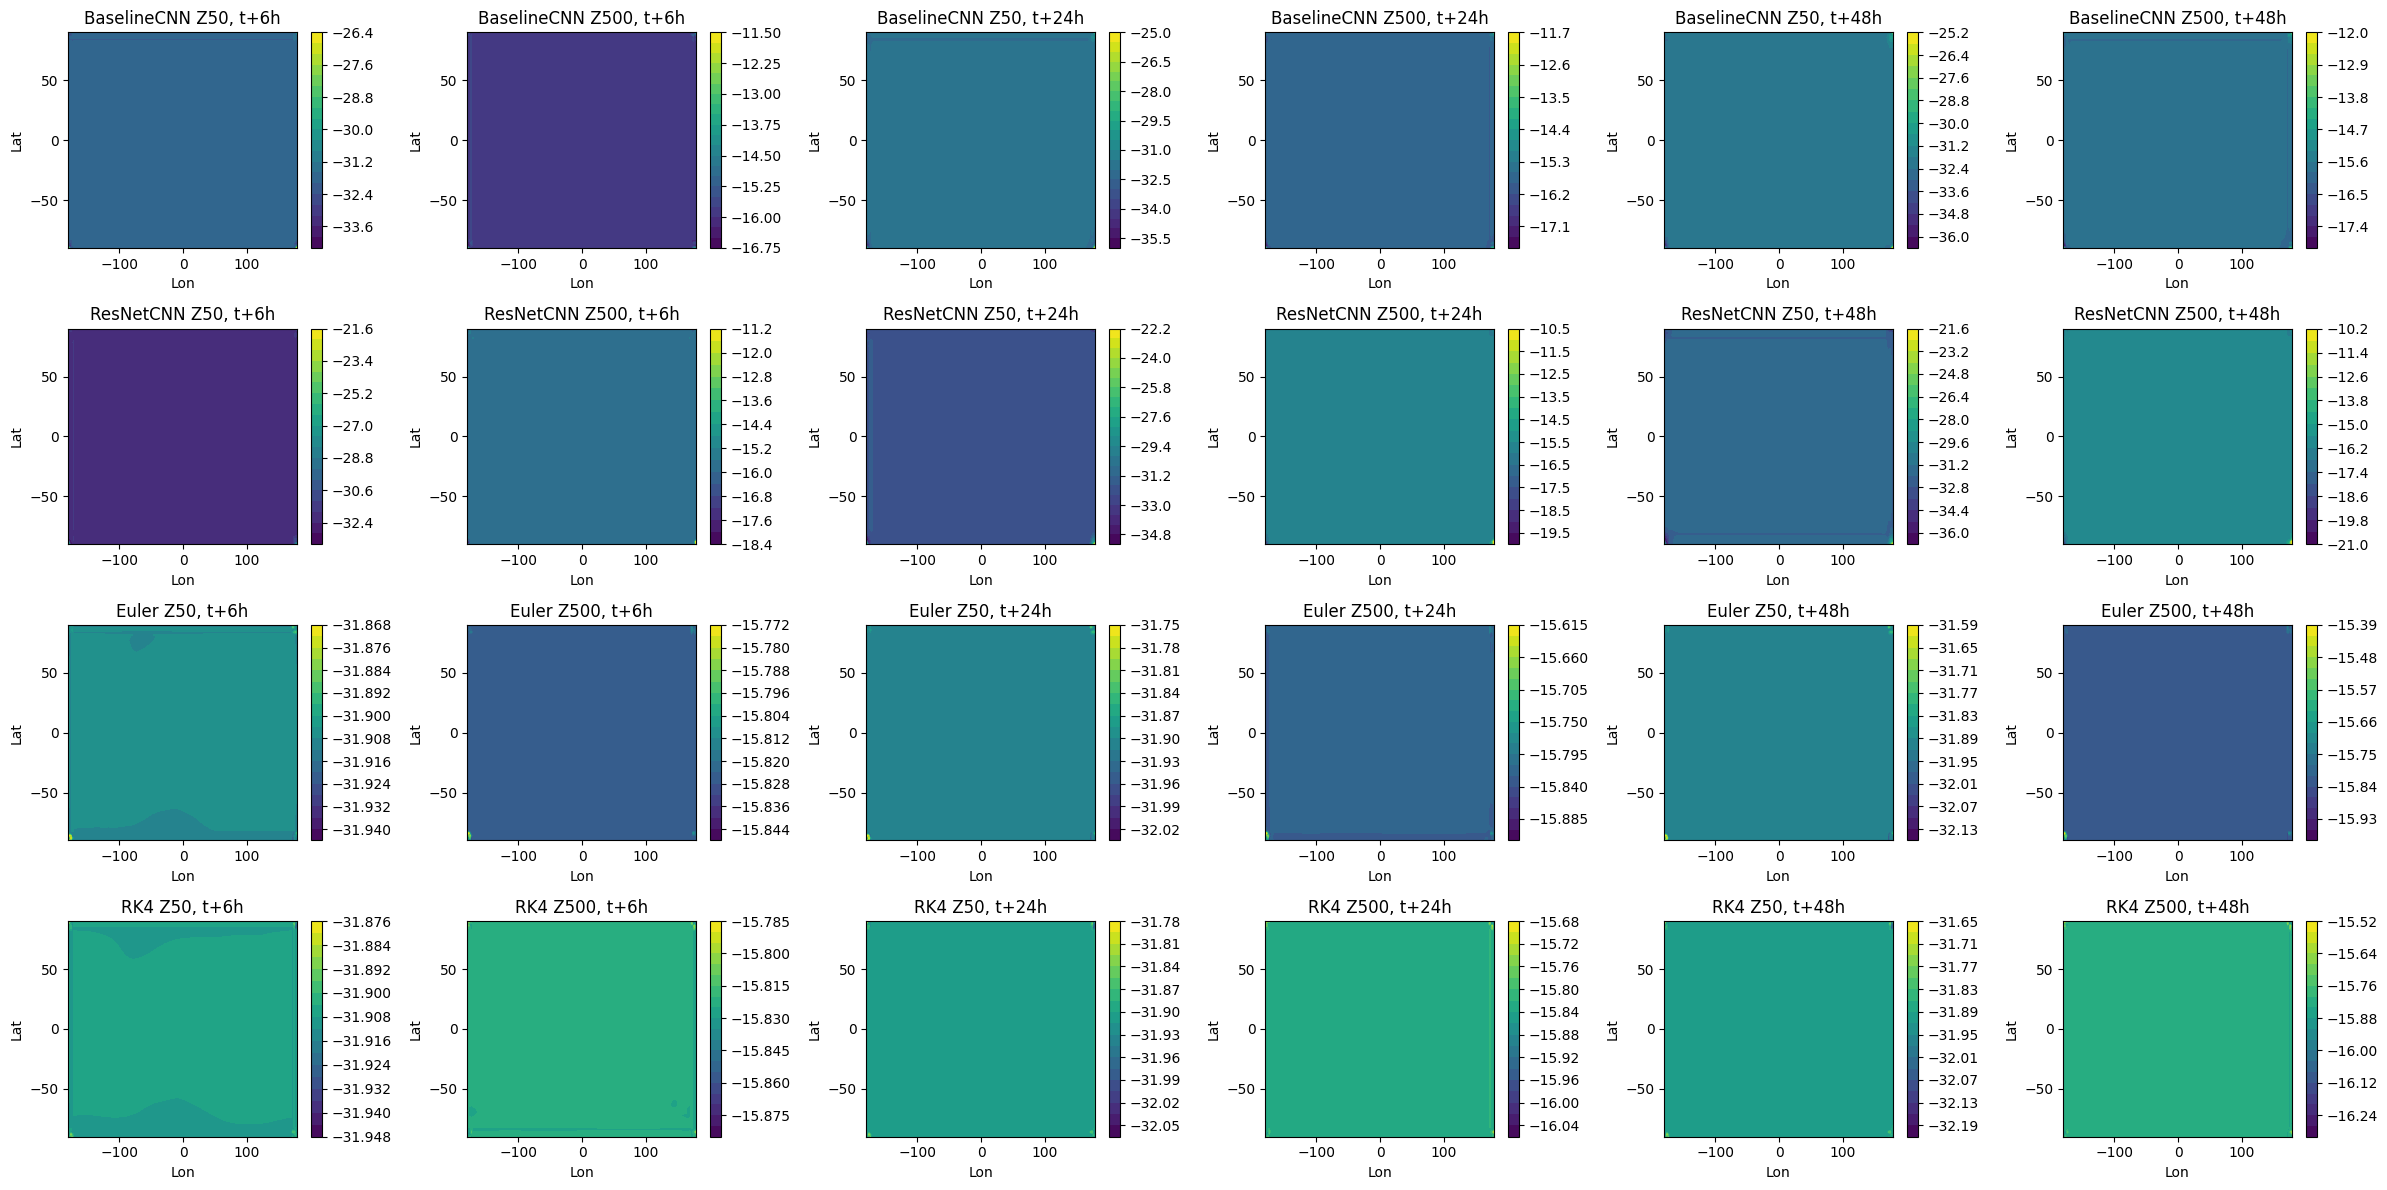

In [ ]:
# PART F Evaluation Metrics & Experiments
import torch
import numpy as np
import matplotlib.pyplot as plt

Ktest = 16  # test rollout horizon (e.g., 4 days if dt=6h)
device = "cuda" if torch.cuda.is_available() else "cpu"

# Use a MultiStepDataset for testing to ensure Ktest steps are available
test_multi_dataset = MultiStepDataset(test_data, K=Ktest)

# Pick some initial conditions to visualize
test_indices = [0, 10, 20]

# Function to compute multi-step rollout MSE
def rollout_mse(model_step, dataset, Ktest):
    mse = np.zeros(Ktest)
    with torch.no_grad():
        for idx in range(len(dataset)):
            x0, y_seq = dataset[idx]  # x0: [C,H,W], y_seq: [K,C,H,W]
            x0 = x0.unsqueeze(0).to(device)
            y_seq = y_seq.to(device)
            x_in = x0
            steps = min(Ktest, y_seq.shape[0])
            for k in range(steps):
                x_out = model_step(x_in)
                target = y_seq[k].unsqueeze(0)
                mse[k] += ((x_out - target) ** 2).mean().item()
                x_in = x_out
        mse /= len(dataset)
    return mse

# One-step test error (MSE)
model_baseline.eval()
one_step_mse = rollout_mse(lambda x: model_baseline(x), test_multi_dataset, 1)
print(f"BaselineCNN one-step test MSE: {one_step_mse[0]:.6f}")

model_resnet.eval()
one_step_mse_resnet = rollout_mse(lambda x: model_resnet(x), test_multi_dataset, 1)
print(f"ResNetCNN one-step test MSE: {one_step_mse_resnet[0]:.6f}")

f_theta_euler.eval()
one_step_mse_euler = rollout_mse(lambda x: euler_step(x, f_theta_euler, dt), test_multi_dataset, 1)
print(f"Euler one-step test MSE: {one_step_mse_euler[0]:.6f}")

f_theta_rk4.eval()
one_step_mse_rk4 = rollout_mse(lambda x: rk4_step(x, f_theta_rk4, dt), test_multi_dataset, 1)
print(f"RK4 one-step test MSE: {one_step_mse_rk4[0]:.6f}")

# Multi-step rollout error vs lead time
mse_baseline = rollout_mse(lambda x: model_baseline(x), test_multi_dataset, Ktest)
mse_resnet   = rollout_mse(lambda x: model_resnet(x), test_multi_dataset, Ktest)
mse_euler    = rollout_mse(lambda x: euler_step(x, f_theta_euler, dt), test_multi_dataset, Ktest)
mse_rk4      = rollout_mse(lambda x: rk4_step(x, f_theta_rk4, dt), test_multi_dataset, Ktest)

plt.figure(figsize=(8,5))
plt.plot(range(1, Ktest+1), mse_baseline, label='BaselineCNN')
plt.plot(range(1, Ktest+1), mse_resnet, label='ResNetCNN')
plt.plot(range(1, Ktest+1), mse_euler, label='Euler')
plt.plot(range(1, Ktest+1), mse_rk4, label='RK4')
plt.xlabel("Forecast step (k)")
plt.ylabel("Mean Squared Error")
plt.title("Multi-step rollout MSE vs lead time")
plt.legend()
plt.grid(True)
plt.show()

# Plot ground truth vs predicted contours for selected initial conditions
lat = ds["latitude"].values
lon = ds["longitude"].values
lead_times = [1, 4, 8]  # lead times to visualize

for idx in test_indices:
    x0, y_seq = test_multi_dataset[idx]
    x0 = x0.unsqueeze(0).to(device)

    fig, axes = plt.subplots(len(models), len(lead_times)*2, figsize=(4*len(lead_times)*2, 3*len(models)))

    for i, (name, model_step) in enumerate(models.items()):
        x_in = x0
        preds = []

        for k in range(max(lead_times)):
            x_out = model_step(x_in)
            x_in = x_out
            if k+1 in lead_times:
                preds.append(x_out.detach().cpu().numpy()[0])

        for j, lead_idx in enumerate(lead_times):
            final_pred = preds[j]
            # Z50
            axes[i, j*2].contourf(lon, lat, final_pred[0], levels=20)
            axes[i, j*2].set_title(f"{name} Z50, t+{lead_idx*6}h")
            axes[i, j*2].set_xlabel("Lon"); axes[i, j*2].set_ylabel("Lat")
            plt.colorbar(axes[i, j*2].collections[0], ax=axes[i, j*2])

            # Z500
            axes[i, j*2+1].contourf(lon, lat, final_pred[1], levels=20)
            axes[i, j*2+1].set_title(f"{name} Z500, t+{lead_idx*6}h")
            axes[i, j*2+1].set_xlabel("Lon"); axes[i, j*2+1].set_ylabel("Lat")
            plt.colorbar(axes[i, j*2+1].collections[0], ax=axes[i, j*2+1])

    plt.tight_layout()
    plt.show()

# Stability discussion
# After inspecting the plots and MSE curves
# - BaselineCNN drifts after long rollouts
# - ResNetCNN blows up
# - Euler-constrained and RK4 are both really accurate only differnce in error
#for first epoch
# Simulations ran under 5 epochs for time sake so could be reason for
#resnet blowing up more than baseline